# Análisis de apariencia externa — imagen individual

*Versión de Traitly utilizada en este tutorial: 0.1.0*

En este tutorial, demostraremos cómo realizar el análisis de apariencia externa de frutas utilizando `FruitExternalAnalyzer` para extraer medidas de morfología y color a partir de imágenes individuales.

Sigue el tutorial
Descarga el cuaderno de Jupyter y las imágenes de muestra para este tutorial [aquí]().

En este tutorial, utilizaremos fotos con fondo blanco, que es un fondo predefinido en `FruitExternalAnalyzer.generate_fruit_mask()`, por lo que no será necesario ajustar los umbrales de color del fondo para eliminarlo. Si necesitas realizar ajustes para eliminar el fondo, consulta la sección de Segmentación de Fondo.

Primero, cargamos la clase `FruitExternalAnalyzer` desde traitly y la imagen a analizar.

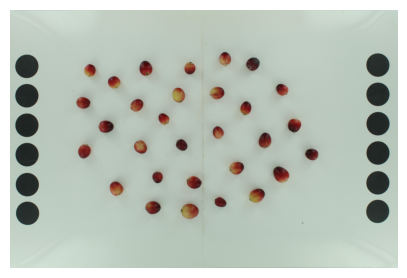

In [ ]:
from traitly.fruit_phenotyping import FruitExternalAnalyzer


path_img = '~/ext_analysis_sample1.jpg'

pic_test = FruitExternalAnalyzer(path_img)

pic_test.load_image()

Ejecuta `setup_measurements()` para detectar las referencias de medición en la imagen (círculos negros). Para más detalles sobre cómo funciona esto, consulta la sección `setup_measurements` de la [Clase External Analyzer](https://github.com/mariameraz/traitly/blob/main/docs/en/tutorials/external.md).

In [6]:
pic_test.setup_measurements()


★ LABEL DETECTION:

★ REFERENCE SIZE:
> Reference size detected:
  - Processing reference box(es) with a confidence threshold >=0.6:
            Ref 1: 453x2532 px, conf: 0.948
            Ref 2: 452x2547 px, conf: 0.942

  - Total circles detected: 12
            Range: [310.2, 314.1] px
            Filtered circles: 11/12 (std > 2)

        . ݁₊ ⊹ . ݁ ⟡ ݁ px/cm density: 124.9 (diameter_cm: 2.5 cm) ⟡ ݁ . ⊹ ₊ ݁.

Note: Default reference diameter (2.5 cm) applied.
        Specify diameter_cm to override this value.


Ahora generemos las máscaras de frutas con `generate_fruit_mask()` usando los parámetros predeterminados de fondo blanco y veamos qué objetos en la imagen fueron detectados como frutas con `detect_fruits()`.

Como podemos ver en los gráficos generados a continuación, las máscaras de algunas frutas tienen espacios sin rellenar y contornos mal definidos. Además, algunas frutas no fueron detectadas (no tienen el contorno verde). Necesitamos modificar algunos parámetros para mejorar tanto las máscaras como la detección, abordemos eso a continuación.

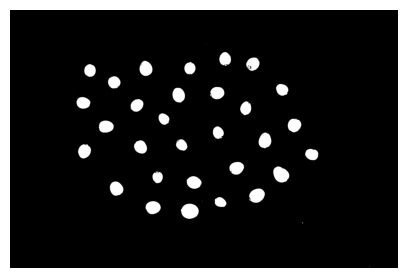

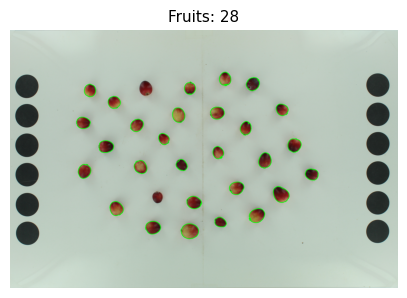


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 28 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.5
        - min_fruit_area: 500


In [7]:
pic_test.generate_fruit_mask(background_color='white')

pic_test.detect_fruits(
    plot=True, plot_size=(5,5),
    contour_thickness=7,
)    

En `generate_fruit_mask()`, las máscaras de frutas se mejoraron aplicando `apply_convex_hull=True`, lo que garantiza que las frutas tengan un contorno suave y cerrado. El parámetro `kernel_blur=5` también ayuda a definir mejor los contornos de las frutas. Tener una buena definición de los contornos de las frutas es fundamental, ya que los cálculos se basan en esto, y cualquier hueco que pueda existir en la máscara de la fruta es eliminado automáticamente al quedar encerrado dentro del contorno de la fruta completa. Aplicar `erosion_px=1` elimina algunos píxeles del contorno de la fruta, lo que ayuda a eliminar partes de la fruta que reflejan el color del fondo, así como porciones del fondo que podrían estar incluidas en la máscara como parte de la fruta y que podrían sesgar las estimaciones del color de la fruta.

En `detect_fruits()`, `min_fruit_circularity=0.4` garantiza que capturemos todas las frutas al reducir el umbral de circularidad, ya que algunas frutas no son muy circulares.

Consulta la [Clase External Analyzer](https://github.com/mariameraz/traitly/blob/main/docs/en/tutorials/external.md) para más detalles sobre cómo funcionan `generate_fruit_mask()` y `detect_fruits()` y sus argumentos disponibles.

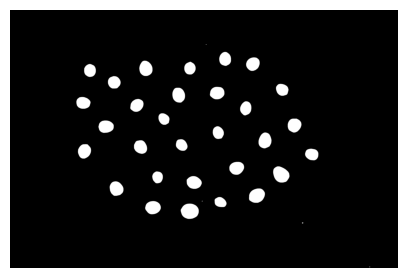

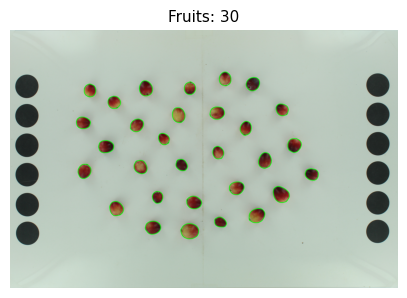


        . ݁₊ ⊹ . ݁ ⟡ ݁ Detected fruits: 30 ⟡ ݁ . ⊹ ₊ ݁.

 > Parameters used:
        - min_fruit_circularity: 0.4
        - min_fruit_area: 500


In [8]:
pic_test.generate_fruit_mask(background_color='white',
                             apply_convex_hull=True,
                             kernel_blur=5,
                             erosion_px=1)

pic_test.detect_fruits(
    plot=True, plot_size=(5,5),
    contour_thickness=7,
    min_fruit_circularity=0.4
)

Ahora que las frutas han sido correctamente detectadas y segmentadas, podemos realizar los análisis morfológicos y de color.

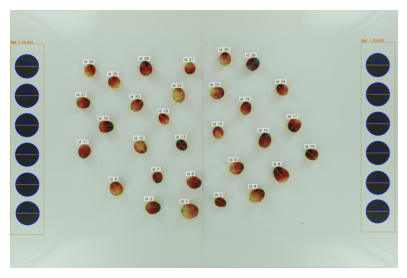

In [9]:
pic_test.analyze_morphology(display_table=False,
                            plot=True,
                            plot_size=(5,5))

pic_test.analyze_color(display_table=False,
                       plot=False)

Cuando se ejecutan `analyze_morphology()` y `analyze_color()`, `save_all()` guardará un archivo CSV con los resultados de cada análisis y una imagen anotada. En la imagen anotada, que puede ser generada tanto por el análisis morfológico como por el de color, podemos verificar que tanto las frutas como las referencias han sido correctamente detectadas.

In [ ]:
pic_test.results.save_all()

Finalmente, puedes guardar los parámetros e información de la sesión de tu análisis con `save_parameters()` para garantizar la reproducibilidad de tus análisis futuros o para utilizarlos en el procesamiento por lotes.

In [ ]:
pic_test.save_parameters()